In [99]:
import pandas as pd

pd.set_option("display.max_rows", 100)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings("ignore")

In [18]:
data = pd.read_csv("cafc-open-gouv-database-2021-01-01-to-2025-09-30-extracted-2025-10-01.csv")

In [19]:
data.columns

Index(['Numéro d'identification / Number ID', 'Date Received / Date reçue',
       'Complaint Received Type', 'Country', 'Province/State',
       'Fraud and Cybercrime Thematic Categories', 'Solicitation Method',
       'Gender', 'Language of Correspondence',
       'Victim Age Range / Tranche d'âge des victimes', 'Complaint Type',
       'Number of Victims / Nombre de victimes',
       'Dollar Loss /pertes financières'],
      dtype='object')

In [20]:
data.head()

,Numéro d'identification / Number ID,Date Received / Date reçue,Complaint Received Type,Country,Province/State,Fraud and Cybercrime Thematic Categories,Solicitation Method,Gender,Language of Correspondence,Victim Age Range / Tranche d'âge des victimes,Complaint Type,Number of Victims / Nombre de victimes,Dollar Loss /pertes financières
0,350308,9/29/2025,Phone,Canada,Ontario,Personal Info,Direct call,Female,English,'30 - 39,Victim,1,$0.00
1,350309,9/29/2025,Phone,Canada,Quebec,Identity Fraud,Other/unknown,Male,English,'50 - 59,Victim,1,$0.00
2,350310,9/29/2025,Phone,Canada,Quebec,Extortion,Direct call,Female,French,'20 - 29,Attempt,0,$0.00
3,350311,9/29/2025,Phone,Canada,Ontario,Identity Fraud,Other/unknown,Female,English,'40 - 49,Victim,1,$0.00
4,350312,9/29/2025,Phone,Canada,Manitoba,Identity Fraud,Other/unknown,Female,English,'60 - 69,Victim,1,$0.00


**Data Cleaning**

In [21]:
# Checking for null values
data.isnull().sum()

Numéro d'identification / Number ID              0
Date Received / Date reçue                       0
Complaint Received Type                          0
Country                                          0
Province/State                                   0
Fraud and Cybercrime Thematic Categories         0
Solicitation Method                              0
Gender                                           0
Language of Correspondence                       0
Victim Age Range / Tranche d'âge des victimes    0
Complaint Type                                   0
Number of Victims / Nombre de victimes           0
Dollar Loss /pertes financières                  0
dtype: int64

In [22]:
# Changing column names
data.columns = ['Number ID', 'Date Received',
       'Complaint Received Type', 'Country', 'Province',
       'Fraud and Cybercrime Thematic Categories', 'Solicitation Method',
       'Gender', 'Language of Correspondence',
       'Victim Age Range', 'Complaint Type',
       'Number of Victims',
       'Dollar Loss']

In [23]:
data.columns

Index(['Number ID', 'Date Received', 'Complaint Received Type', 'Country',
       'Province', 'Fraud and Cybercrime Thematic Categories',
       'Solicitation Method', 'Gender', 'Language of Correspondence',
       'Victim Age Range', 'Complaint Type', 'Number of Victims',
       'Dollar Loss'],
      dtype='object')

In [24]:
# Checking datatypes
data.dtypes

Number ID                                    int64
Date Received                               object
Complaint Received Type                     object
Country                                     object
Province                                    object
Fraud and Cybercrime Thematic Categories    object
Solicitation Method                         object
Gender                                      object
Language of Correspondence                  object
Victim Age Range                            object
Complaint Type                              object
Number of Victims                            int64
Dollar Loss                                 object
dtype: object

In [25]:
data["Date Received"] = pd.to_datetime(data["Date Received"])

In [26]:
data["Victim Age Range"] = data["Victim Age Range"].str.strip("'")

In [27]:
data["Dollar Loss"] = data["Dollar Loss"].str.strip("$")

In [28]:
data["Dollar Loss"] = data["Dollar Loss"].str.replace(",", "").astype(float)

In [29]:
data.dtypes

Number ID                                            int64
Date Received                               datetime64[ns]
Complaint Received Type                             object
Country                                             object
Province                                            object
Fraud and Cybercrime Thematic Categories            object
Solicitation Method                                 object
Gender                                              object
Language of Correspondence                          object
Victim Age Range                                    object
Complaint Type                                      object
Number of Victims                                    int64
Dollar Loss                                        float64
dtype: object

In [30]:
# Checking for duplicates
data.duplicated().sum()

0

In [34]:
set(data["Country"].unique())

{'Afghanistan',
 'Algeria',
 'Angola',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Australia',
 'Austria',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belgium',
 'Benin',
 'Bermuda',
 'Bolivia, Plurinational State of',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Congo',
 'Congo, The Democratic Republic of the',
 'Costa Rica',
 'Croatia',
 'Curaçao',
 'Cyprus',
 'Czech Republic',
 "Côte d'Ivoire",
 'Denmark',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Estonia',
 'Ethiopia',
 'Fiji',
 'Finland',
 'France',
 'France, Metropolitan',
 'Gabon',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Guadeloupe',
 'Guam',
 'Guatemala',
 'Guernsey',
 'Guinea',
 'Guyana',
 'Haiti',
 'Hong Kong',
 'Hungary',
 'Iceland',
 'India',
 'Indonesia',
 'Iran, Islamic Republic of',
 'Iraq',
 'Ireland'

In [48]:
# Normalize country names
data["Country"].replace({
    "Bolivia, Plurinational State of" : "Bolivia",
    "Congo, The Democratic Republic of the" : "Congo",
    "France, Metropolitan" : "France",
    "Iran, Islamic Republic of" : "Iran",
    "Korea, Republic of" : "South Korea",
    "Macedonia, The Former Yugoslav Republic of" : "Macedonia",
    "Palestinian Territory, Occupied" : "Palestinian",
    "Taiwan, Province of China" : "Taiwan",
    "Tanzania, United Republic of" : "Tanzania",
    "United States Minor Outlying Islands" : "Others",
    "Not Specified" : "Others",
    "Unknown" : "Others",
    "Venezuela, Bolivarian Republic of" : "Venezuela",
    "Viet Nam" : "Vietnam",
    "Virgin Islands, British" : "British Virgin Islands"
}, inplace = True)

In [55]:
data["Province"].replace("Not Specified", "Others", inplace = True)

**EDA**

In [59]:
data.describe()

,Number ID,Date Received,Number of Victims,Dollar Loss
count,350361.000000,350361,350361.000000,3.503610e+05
mean,175181.000000,2022-12-05 08:48:59.751856384,0.649076,7.670432e+03
min,1.000000,2021-01-02 00:00:00,0.000000,0.000000e+00
25%,87591.000000,2021-10-18 00:00:00,0.000000,0.000000e+00
50%,175181.000000,2022-09-16 00:00:00,1.000000,0.000000e+00
75%,262771.000000,2023-12-12 00:00:00,1.000000,0.000000e+00
max,350361.000000,2025-09-29 00:00:00,1.000000,2.361500e+07
std,101140.653169,NaN,0.477260,1.029056e+05


In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350361 entries, 0 to 350360
Data columns (total 13 columns):
 #   Column                                    Non-Null Count   Dtype         
---  ------                                    --------------   -----         
 0   Number ID                                 350361 non-null  int64         
 1   Date Received                             350361 non-null  datetime64[ns]
 2   Complaint Received Type                   350361 non-null  object        
 3   Country                                   350361 non-null  object        
 4   Province                                  350361 non-null  object        
 5   Fraud and Cybercrime Thematic Categories  350361 non-null  object        
 6   Solicitation Method                       350361 non-null  object        
 7   Gender                                    350361 non-null  object        
 8   Language of Correspondence                350361 non-null  object        
 9   Victim Age Rang

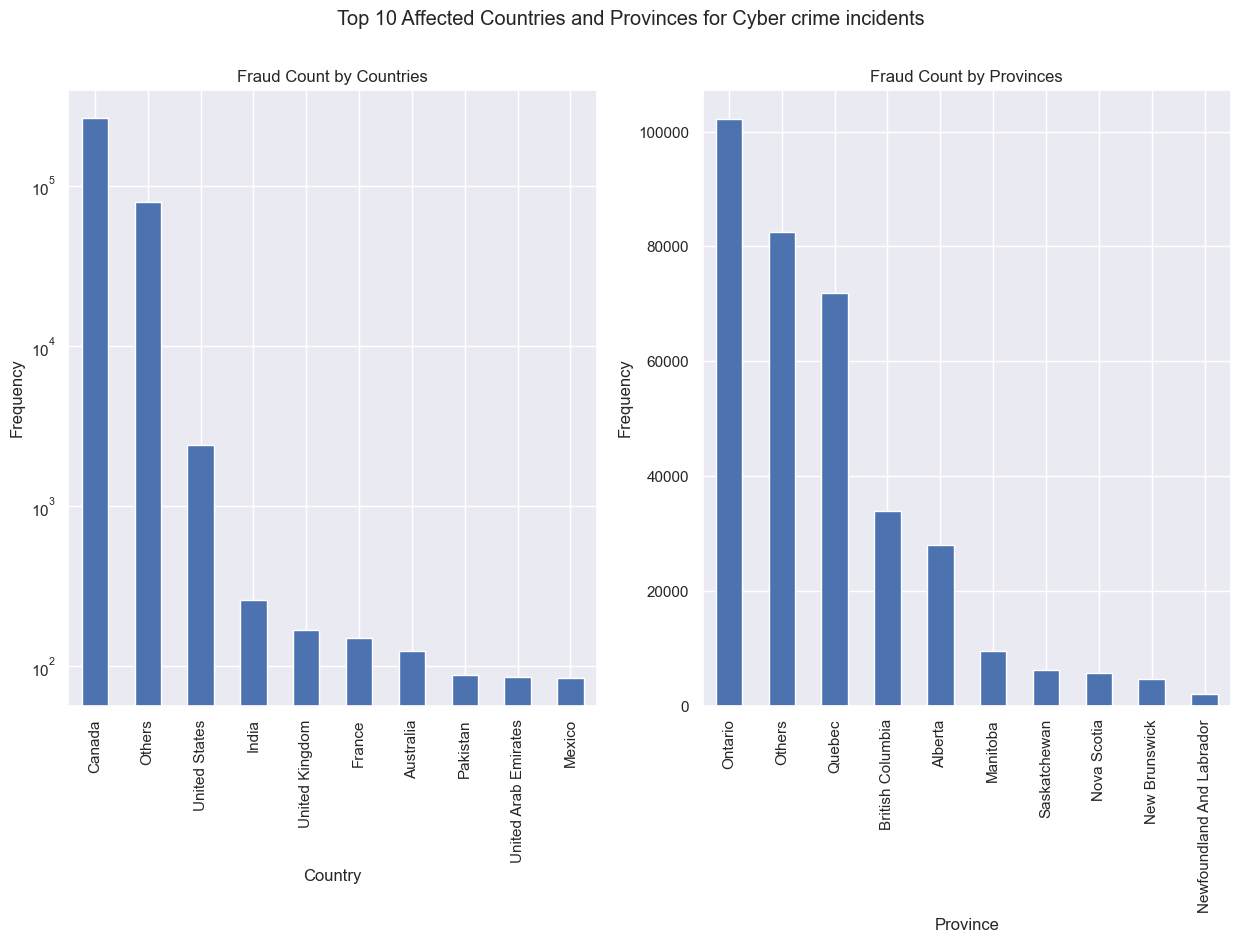

In [94]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = [15,8])
fig.suptitle("Top 10 Affected Countries and Provinces for Cyber crime incidents")

data["Country"].value_counts().head(10).plot(kind = "bar", ax =  ax1)
ax1.set_title("Fraud Count by Countries")
ax1.set_ylabel("Frequency")
ax1.set_yscale("log")

data["Province"].value_counts().head(10).plot(kind = "bar", ax =  ax2)
ax2.set_title("Fraud Count by Provinces")
ax2.set_ylabel("Frequency")

plt.show()

In [98]:
data.head()

,Number ID,Date Received,Complaint Received Type,Country,Province,Fraud and Cybercrime Thematic Categories,Solicitation Method,Gender,Language of Correspondence,Victim Age Range,Complaint Type,Number of Victims,Dollar Loss
0,350308,2025-09-29,Phone,Canada,Ontario,Personal Info,Direct call,Female,English,30 - 39,Victim,1,0.0
1,350309,2025-09-29,Phone,Canada,Quebec,Identity Fraud,Other/unknown,Male,English,50 - 59,Victim,1,0.0
2,350310,2025-09-29,Phone,Canada,Quebec,Extortion,Direct call,Female,French,20 - 29,Attempt,0,0.0
3,350311,2025-09-29,Phone,Canada,Ontario,Identity Fraud,Other/unknown,Female,English,40 - 49,Victim,1,0.0
4,350312,2025-09-29,Phone,Canada,Manitoba,Identity Fraud,Other/unknown,Female,English,60 - 69,Victim,1,0.0


In [105]:
data["Fraud and Cybercrime Thematic Categories"].unique()

array(['Personal Info', 'Identity Fraud', 'Extortion', 'Investments',
       'Unknown', 'Service', 'Other', 'Spear Phishing', 'Romance',
       'Phishing', 'Job', 'Bank Investigator',
       'Emergency (Jail, Accident, Hospital, Help)', 'Merchandise',
       'Prize', 'Loan', 'Vendor Fraud', 'Timeshare', 'Recovery Pitch',
       'False Billing', 'Psychics', 'Collection Agency', 'GRANT',
       'Foreign Money Offer', 'Charity / Donation',
       'Counterfeit Merchandise', 'Incomplete', 'Vacation', 'Credit Card',
       'Telecom Fraud', 'Pyramid', 'Survey', 'Directory', 'Spoofing',
       'Health', 'Unauthorized Charge', 'Office Supplies',
       'Modem-Hijacking', 'Fraudulent Cheque'], dtype=object)

In [123]:
data["Date Received"].dt.to_period("y").value_counts().sort_index()

Date Received
2021    107796
2022     93091
2023     64016
2024     51728
2025     33730
Freq: A-DEC, Name: count, dtype: int64

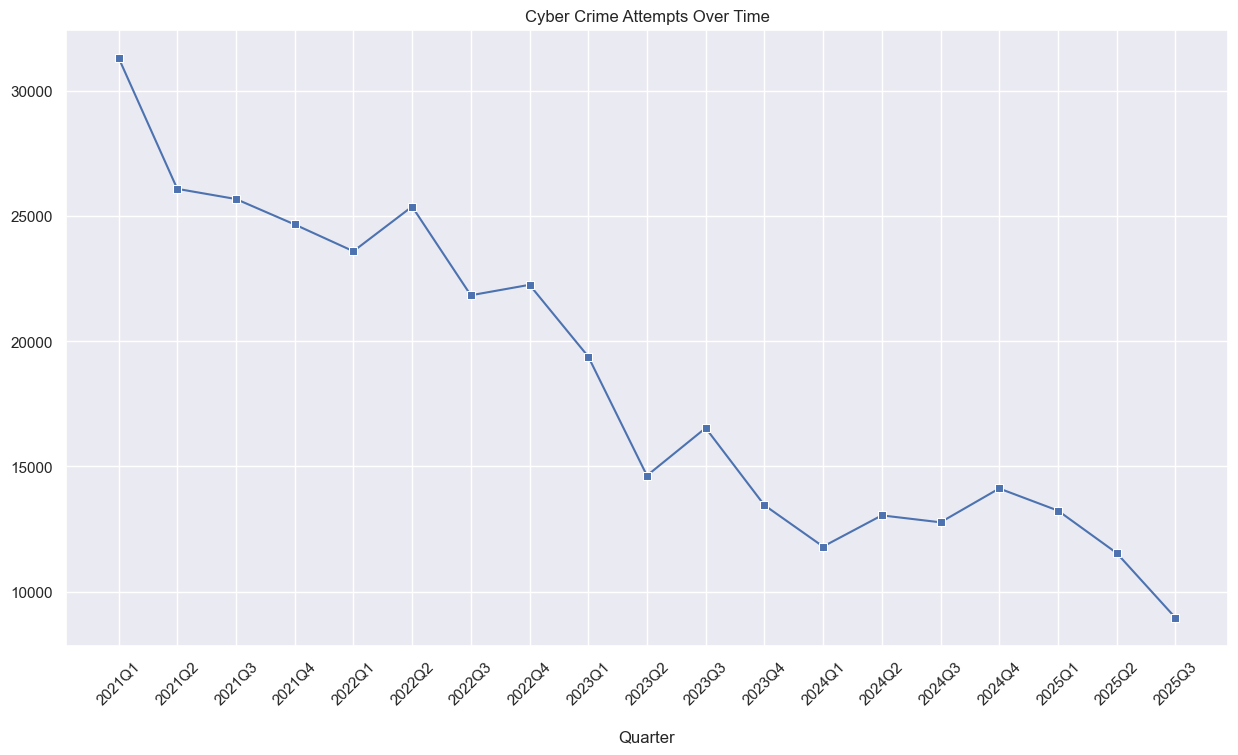

In [140]:
time_df = data["Date Received"].dt.to_period("q").value_counts().sort_index()
plt.figure(figsize = [15,8])
sns.lineplot(x = time_df.index.astype(str), y = time_df.values, marker = "s")
plt.xticks(rotation = 45)
plt.title("Cyber Crime Attempts Over Time")
plt.xlabel("\nQuarter")
plt.show()